# World Happiness Report: Trend Analysis & Predictive Modeling (2015–2019)

**Objective:** Analyze how national well-being drivers — GDP per capita, social support, healthy life expectancy, freedom, perceptions of corruption, and generosity — relate to self-reported happiness across 150+ countries from 2015–2019, and build models to predict happiness rank.

**Data:** [World Happiness Report](https://worldhappiness.report/) yearly datasets (2015–2019), each with different column names, formats, and country coverage.

**Approach:**
1. Reconcile 5 years of inconsistently-labeled survey data into a single clean dataset
2. Explore trends in happiness scores over time, by country, and by region
3. Identify which features correlate most strongly with happiness
4. Train and compare three regression models — Linear Regression, KNN, and Random Forest — to predict 2019 happiness rank, using 2015–2018 as training data and 2019 as a held-out test set

**Attribution:** This was originally a two-person team project. My primary contributions: data cleaning, correlation analysis, and data modeling.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler


## 1. Data Loading

Each year's report was published as a separate CSV with its own column naming convention, so we load them individually before reconciling schemas.

In [2]:
df2015 = pd.read_csv('2015.csv')
df2016 = pd.read_csv('2016.csv')
df2017 = pd.read_csv('2017.csv')
df2018 = pd.read_csv('2018.csv')
df2019 = pd.read_csv('2019.csv')  # held out as the test set

df2015.head()


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


## 2. Data Cleaning & Reconciliation

Before the five years can be combined, we need to:
- Tag each row with its year
- Check for duplicate or missing country entries
- Confirm which countries are present/absent across years
- Standardize column names (each year uses different labels for the same concept, e.g. `Family` in 2015–2017 vs. `Social support` in 2018–2019)
- Standardize country name spelling/capitalization
- Merge into one dataframe and handle remaining missing values

In [3]:
# Tag each dataframe with its year so it can be tracked after merging
df2015['Year'] = 2015
df2016['Year'] = 2016
df2017['Year'] = 2017
df2018['Year'] = 2018
df2019['Year'] = 2019


In [4]:
# Check for duplicate or missing country entries in each dataframe
dfArr = [df2015, df2016, df2017, df2018, df2019]

for i, df in enumerate(dfArr):
    year = 2015 + i
    field = 'Country' if i <= 2 else 'Country or region'
    dup = df[field].duplicated().any()
    na = df[field].isna().sum() > 0
    print(f"{year}: duplicate countries = {dup}, missing countries = {na}")


2015: duplicate countries = False, missing countries = False
2016: duplicate countries = False, missing countries = False
2017: duplicate countries = False, missing countries = False
2018: duplicate countries = False, missing countries = False
2019: duplicate countries = False, missing countries = False


In [5]:
def field_equiv_check(dfArray, field, year=2015):
    """Compare a field (e.g. 'Country') across consecutive years' dataframes
    and report which entries are missing on either side."""
    if year > 2017 and field == 'Country':
        field = 'Country or region'
    reference = dfArray[0][field].values

    for i, df in enumerate(dfArray[1:], start=1):
        current_field = 'Country or region' if (year + i > 2017 and field == 'Country') else field
        current = df[current_field].values

        if len(current) != len(reference) or not (current == reference).all():
            print(f"Mismatch between {year} and {year + i} on '{field}':")
            print(f"  Missing from {year}: {set(reference) - set(current)}")
            print(f"  Missing from {year + i}: {set(current) - set(reference)}\n")
        else:
            print(f"{year + i} matches {year} on '{field}'")


In [6]:
field_equiv_check(dfArr, 'Country')
print()
field_equiv_check([df2016, df2017, df2018, df2019], 'Country', 2016)
print()
field_equiv_check([df2017, df2018, df2019], 'Country', 2017)
print()
field_equiv_check([df2018, df2019], 'Country', 2018)

# Country lists differ year to year mostly due to naming inconsistencies
# (e.g. "Somaliland region" vs "Somaliland Region", "Taiwan Province of China" vs "Taiwan"),
# not because countries actually enter/exit the survey. These get unified below.


Mismatch between 2015 and 2016 on 'Country':
  Missing from 2015: {'Djibouti', 'Mozambique', 'Lesotho', 'Somaliland region', 'Oman', 'Swaziland', 'Central African Republic'}
  Missing from 2016: {'Somaliland Region', 'Somalia', 'South Sudan', 'Namibia', 'Puerto Rico', 'Belize'}

Mismatch between 2015 and 2017 on 'Country':
  Missing from 2015: {'Laos', 'Taiwan', 'Djibouti', 'Somaliland region', 'Oman', 'Comoros', 'Swaziland', 'Hong Kong', 'Suriname'}
  Missing from 2017: {'Somalia', 'Taiwan Province of China', 'South Sudan', 'Namibia', 'Hong Kong S.A.R., China', 'Belize'}

Mismatch between 2015 and 2018 on 'Country':
  Missing from 2015: {'Djibouti', 'North Cyprus', 'Trinidad and Tobago', 'Somaliland region', 'Oman', 'Comoros', 'Swaziland', 'Suriname'}
  Missing from 2018: {'Somalia', 'Northern Cyprus', 'Belize', 'South Sudan', 'Namibia', 'Trinidad & Tobago'}

Mismatch between 2015 and 2019 on 'Country':
  Missing from 2015: {'Macedonia', 'Djibouti', 'North Cyprus', 'Sudan', 'Trinidad 

In [7]:
# Column names also differ across years — inspect before reconciling
dfArr = [df2015, df2016, df2017, df2018, df2019]
for i, df in enumerate(dfArr):
    print(i + 2015, ':', list(df.columns))


2015 : ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']
2016 : ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']
2017 : ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual', 'Year']
2018 : ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Year']
2019 : ['Overall rank', 'Country or region', '

**Column mapping used going forward** (target name ← source name(s)):

| Target column | 2015/2016 | 2017 | 2018/2019 |
|---|---|---|---|
| Overall rank | Happiness Rank | Happiness.Rank | Overall rank |
| Score | Happiness Score | Happiness.Score | Score |
| GDP per capita | Economy (GDP per Capita) | Economy..GDP.per.Capita. | GDP per capita |
| Social support | Family | Family | Social support |
| Healthy life expectancy | Health (Life Expectancy) | Health..Life.Expectancy. | Healthy life expectancy |
| Freedom to make life choices | Freedom | Freedom | Freedom to make life choices |
| Perceptions of corruption | Trust (Government Corruption) | Trust..Government.Corruption. | Perceptions of corruption |

2018/2019 data has no `Dystopia Residual` or separate `Region` column — `Region` is backfilled from earlier years after merging.

In [8]:
df2015 = df2015.rename(columns={
    'Happiness Rank': 'Overall rank', 'Happiness Score': 'Score',
    'Economy (GDP per Capita)': 'GDP per capita', 'Freedom': 'Freedom to make life choices',
    'Health (Life Expectancy)': 'Healthy life expectancy',
    'Trust (Government Corruption)': 'Perceptions of corruption', 'Family': 'Social support'
})
df2016 = df2016.rename(columns={
    'Happiness Rank': 'Overall rank', 'Happiness Score': 'Score',
    'Economy (GDP per Capita)': 'GDP per capita', 'Freedom': 'Freedom to make life choices',
    'Health (Life Expectancy)': 'Healthy life expectancy',
    'Trust (Government Corruption)': 'Perceptions of corruption', 'Family': 'Social support'
})
df2017 = df2017.rename(columns={
    'Happiness.Rank': 'Overall rank', 'Happiness.Score': 'Score',
    'Whisker.high': 'Whisker High', 'Whisker.low': 'Whisker Low',
    'Economy..GDP.per.Capita.': 'GDP per capita', 'Freedom': 'Freedom to make life choices',
    'Health..Life.Expectancy.': 'Healthy life expectancy',
    'Trust..Government.Corruption.': 'Perceptions of corruption',
    'Dystopia.Residual': 'Dystopia Residual', 'Family': 'Social support'
})
df2018 = df2018.rename(columns={'Country or region': 'Country'})
df2019 = df2019.rename(columns={'Country or region': 'Country'})


In [9]:
# Unify country name spelling/capitalization across years
df2017['Country'] = df2017['Country'].replace({
    'Taiwan Province of China': 'Taiwan', 'Hong Kong S.A.R., China': 'Hong Kong',
    'Trinidad & Tobago': 'Trinidad And Tobago'
})
df2018['Country'] = df2018['Country'].replace({'Trinidad & Tobago': 'Trinidad And Tobago'})
df2019['Country'] = df2019['Country'].replace({
    'North Macedonia': 'Macedonia', 'Trinidad & Tobago': 'Trinidad And Tobago'
})

for df in [df2015, df2016, df2017, df2018, df2019]:
    df['Country'] = df['Country'].str.title()


In [10]:
# Merge 2015-2018 into one training dataset (2019 is held out separately as the test set)
dfArr = [df2015, df2016, df2017, df2018]
df_all_years = pd.concat(dfArr, ignore_index=True)

# Drop confidence-interval columns not needed for analysis
df_all_years = df_all_years.drop(columns=['Standard Error', 'Lower Confidence Interval',
                                           'Upper Confidence Interval', 'Whisker High', 'Whisker Low'])
df_all_years.head()


,Country,Region,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Generosity,Dystopia Residual,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


In [11]:
# Region is missing for some entries (e.g. Northern Cyprus, Gambia) — assign known values,
# then backfill/forward-fill each country's region using its other years' data
df_all_years.loc[df_all_years['Country'] == 'Northern Cyprus', 'Region'] = 'Western Europe'
df_all_years.loc[df_all_years['Country'] == 'Gambia', 'Region'] = 'Sub-Saharan Africa'

df_all_years['Region'] = df_all_years.groupby('Country')['Region'].transform(lambda s: s.ffill().bfill())


In [12]:
# Remaining missing values: only 'Perceptions of corruption' for UAE in 2018.
# Impute using the mean of that country's other years' values.
df_all_years.loc[
    (df_all_years['Country'] == 'United Arab Emirates') &
    (df_all_years['Year'] == 2018) &
    (df_all_years['Perceptions of corruption'].isna()),
    'Perceptions of corruption'
] = df_all_years[df_all_years['Country'] == 'United Arab Emirates']['Perceptions of corruption'].mean()

df_all_years.describe()


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Generosity,Dystopia Residual,Year
count,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,470.000000,626.000000
mean,78.747604,5.372021,0.918764,1.045891,0.584299,0.415706,0.129499,0.226981,2.092717,2016.493610
std,45.219609,1.131774,0.409808,0.328946,0.241948,0.154943,0.108492,0.126854,0.565772,1.120339
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580,2015.000000
25%,40.000000,4.497750,0.606755,0.847945,0.404143,0.310500,0.056616,0.137263,1.737975,2015.000000
50%,79.000000,5.307000,0.983705,1.081274,0.632553,0.434635,0.094095,0.208581,2.094640,2016.000000
75%,118.000000,6.187250,1.239502,1.283387,0.772957,0.538998,0.161593,0.290915,2.455575,2017.000000
max,158.000000,7.632000,2.096000,1.644000,1.030000,0.724000,0.551910,0.838075,3.837720,2018.000000


## 3. Exploratory Data Analysis

### 3.1 Happiness score over time

In [13]:
for year in df_all_years["Year"].unique():
    print(f"\nHappiness Score Statistics for {year}")
    print(df_all_years[df_all_years["Year"] == year]["Score"].describe())



Happiness Score Statistics for 2015
count    158.000000
mean       5.375734
std        1.145010
min        2.839000
25%        4.526000
50%        5.232500
75%        6.243750
max        7.587000
Name: Score, dtype: float64

Happiness Score Statistics for 2016
count    157.000000
mean       5.382185
std        1.141674
min        2.905000
25%        4.404000
50%        5.314000
75%        6.269000
max        7.526000
Name: Score, dtype: float64

Happiness Score Statistics for 2017
count    155.000000
mean       5.354019
std        1.131230
min        2.693000
25%        4.505500
50%        5.279000
75%        6.101500
max        7.537000
Name: Score, dtype: float64

Happiness Score Statistics for 2018
count    156.000000
mean       5.375917
std        1.119506
min        2.905000
25%        4.453750
50%        5.378000
75%        6.168500
max        7.632000
Name: Score, dtype: float64


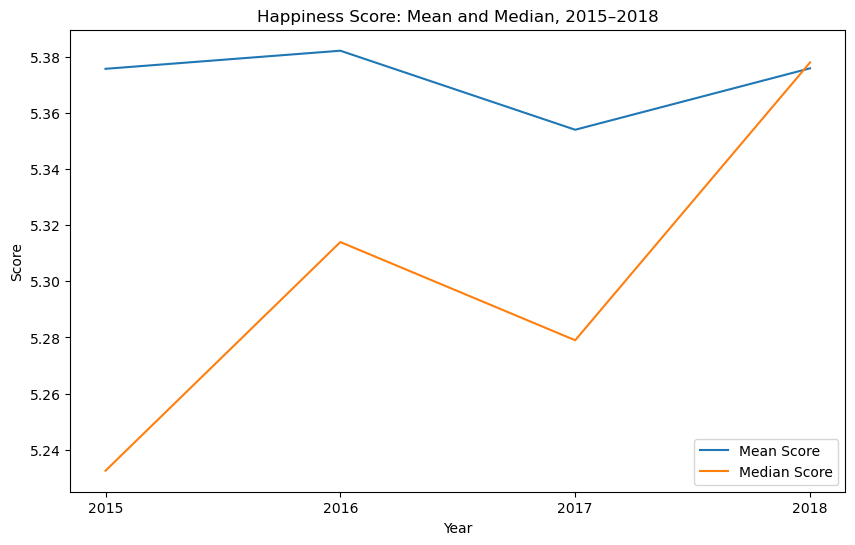

In [14]:
central_tendencies = df_all_years.groupby("Year")["Score"].agg(["mean", "median"]).reset_index()
plt.figure(figsize=(10, 6))
plt.plot(central_tendencies["Year"], central_tendencies["mean"], label='Mean Score')
plt.plot(central_tendencies["Year"], central_tendencies["median"], label='Median Score')
plt.title("Happiness Score: Mean and Median, 2015–2018")
plt.xlabel("Year")
plt.ylabel("Score")
plt.xticks(central_tendencies["Year"])
plt.legend()
plt.show()

# Mean score rose from 2015 to 2016, dropped through 2017, then partially recovered by 2018.


### 3.2 Which countries changed rank the most?

In [15]:
rank_pivot = df_all_years.pivot(index="Country", columns="Year", values="Overall rank")
rank_pivot["std_dev"] = rank_pivot.std(axis=1)
rank_pivot["improvement"] = rank_pivot[2015] - rank_pivot[2018]

most_stable = rank_pivot.sort_values("std_dev").head(10)
improved_countries = rank_pivot[rank_pivot["improvement"] > 0][[2015, 2018, "improvement"]] \
    .sort_values("improvement", ascending=False)

print("Most stable countries (lowest rank variance):\n", most_stable[[2015, 2016, 2017, 2018]])
print("\nMost improved countries (2015 → 2018):\n", improved_countries)


Most stable countries (lowest rank variance):
 Year         2015  2016  2017  2018
Country                            
Suriname     40.0  40.0   NaN   NaN
Australia    10.0   9.0  10.0  10.0
New Zealand   9.0   8.0   8.0   8.0
Netherlands   7.0   7.0   6.0   6.0
Austria      13.0  12.0  13.0  12.0
Iceland       2.0   3.0   3.0   4.0
Sweden        8.0  10.0   9.0   9.0
Costa Rica   12.0  14.0  12.0  13.0
Canada        5.0   6.0   7.0   7.0
Denmark       3.0   1.0   2.0   3.0

Most improved countries (2015 → 2018):
 Year          2015   2018  improvement
Country                               
Ivory Coast  151.0  107.0         44.0
Gabon        143.0  103.0         40.0
Latvia        89.0   53.0         36.0
Hungary      104.0   69.0         35.0
Romania       86.0   52.0         34.0
...            ...    ...          ...
Kenya        125.0  124.0          1.0
Argentina     30.0   29.0          1.0
New Zealand    9.0    8.0          1.0
Netherlands    7.0    6.0          1.0
Uruguay     

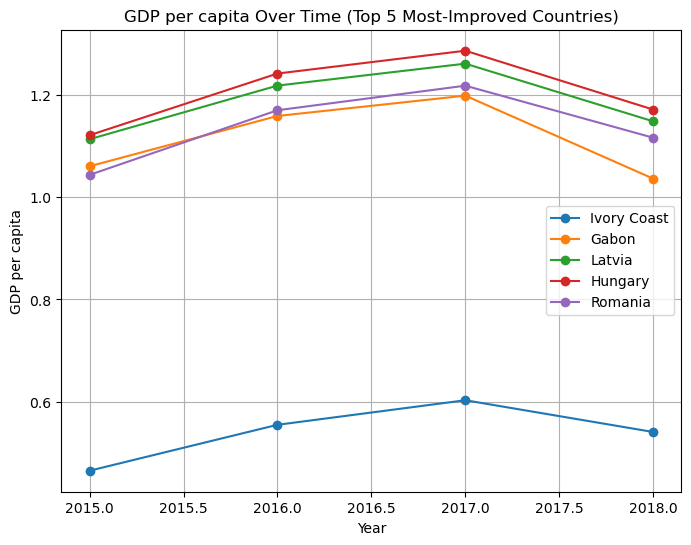

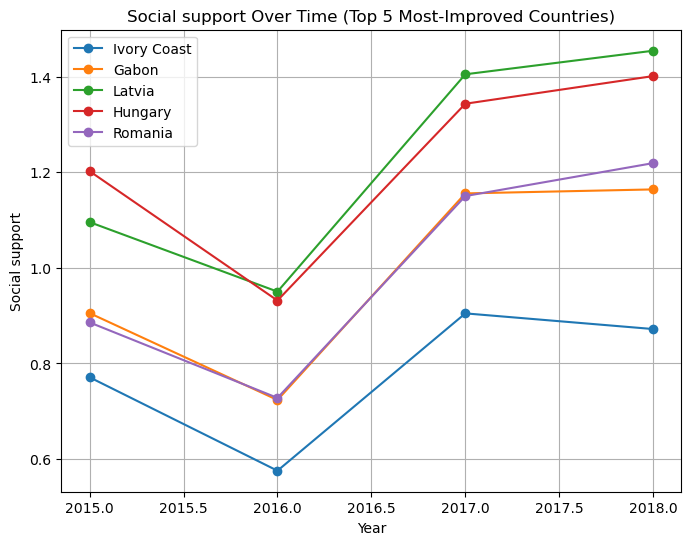

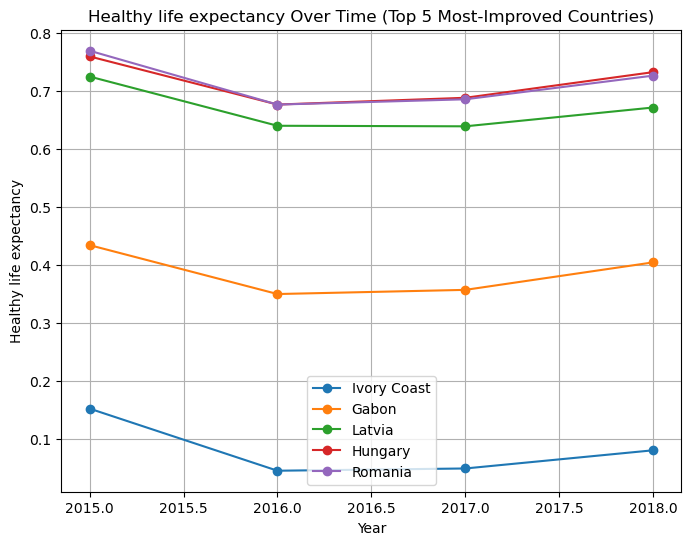

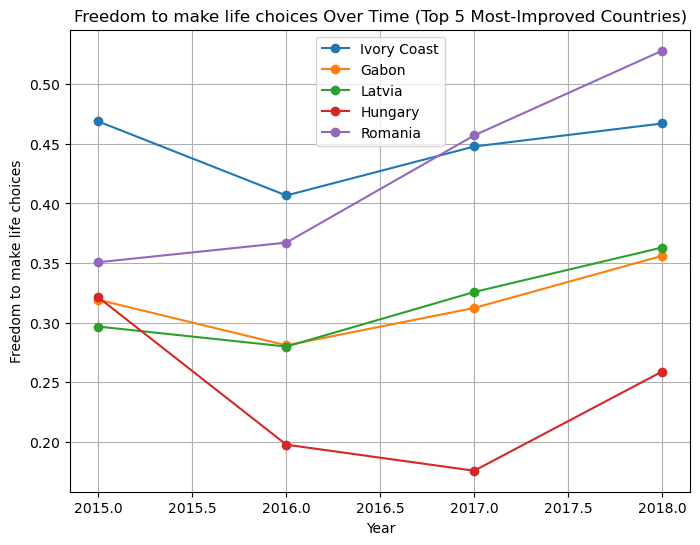

In [16]:
top_improved = improved_countries.head(5).index.tolist()

for feature in ['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices']:
    plt.figure(figsize=(8, 6))
    for country in top_improved:
        values = df_all_years[df_all_years['Country'] == country].sort_values('Year')[['Year', feature]]
        plt.plot(values['Year'], values[feature], marker='o', label=country)
    plt.title(f"{feature} Over Time (Top 5 Most-Improved Countries)")
    plt.xlabel("Year")
    plt.ylabel(feature)
    plt.legend()
    plt.grid()
    plt.show()


### 3.3 Feature relationships with happiness score

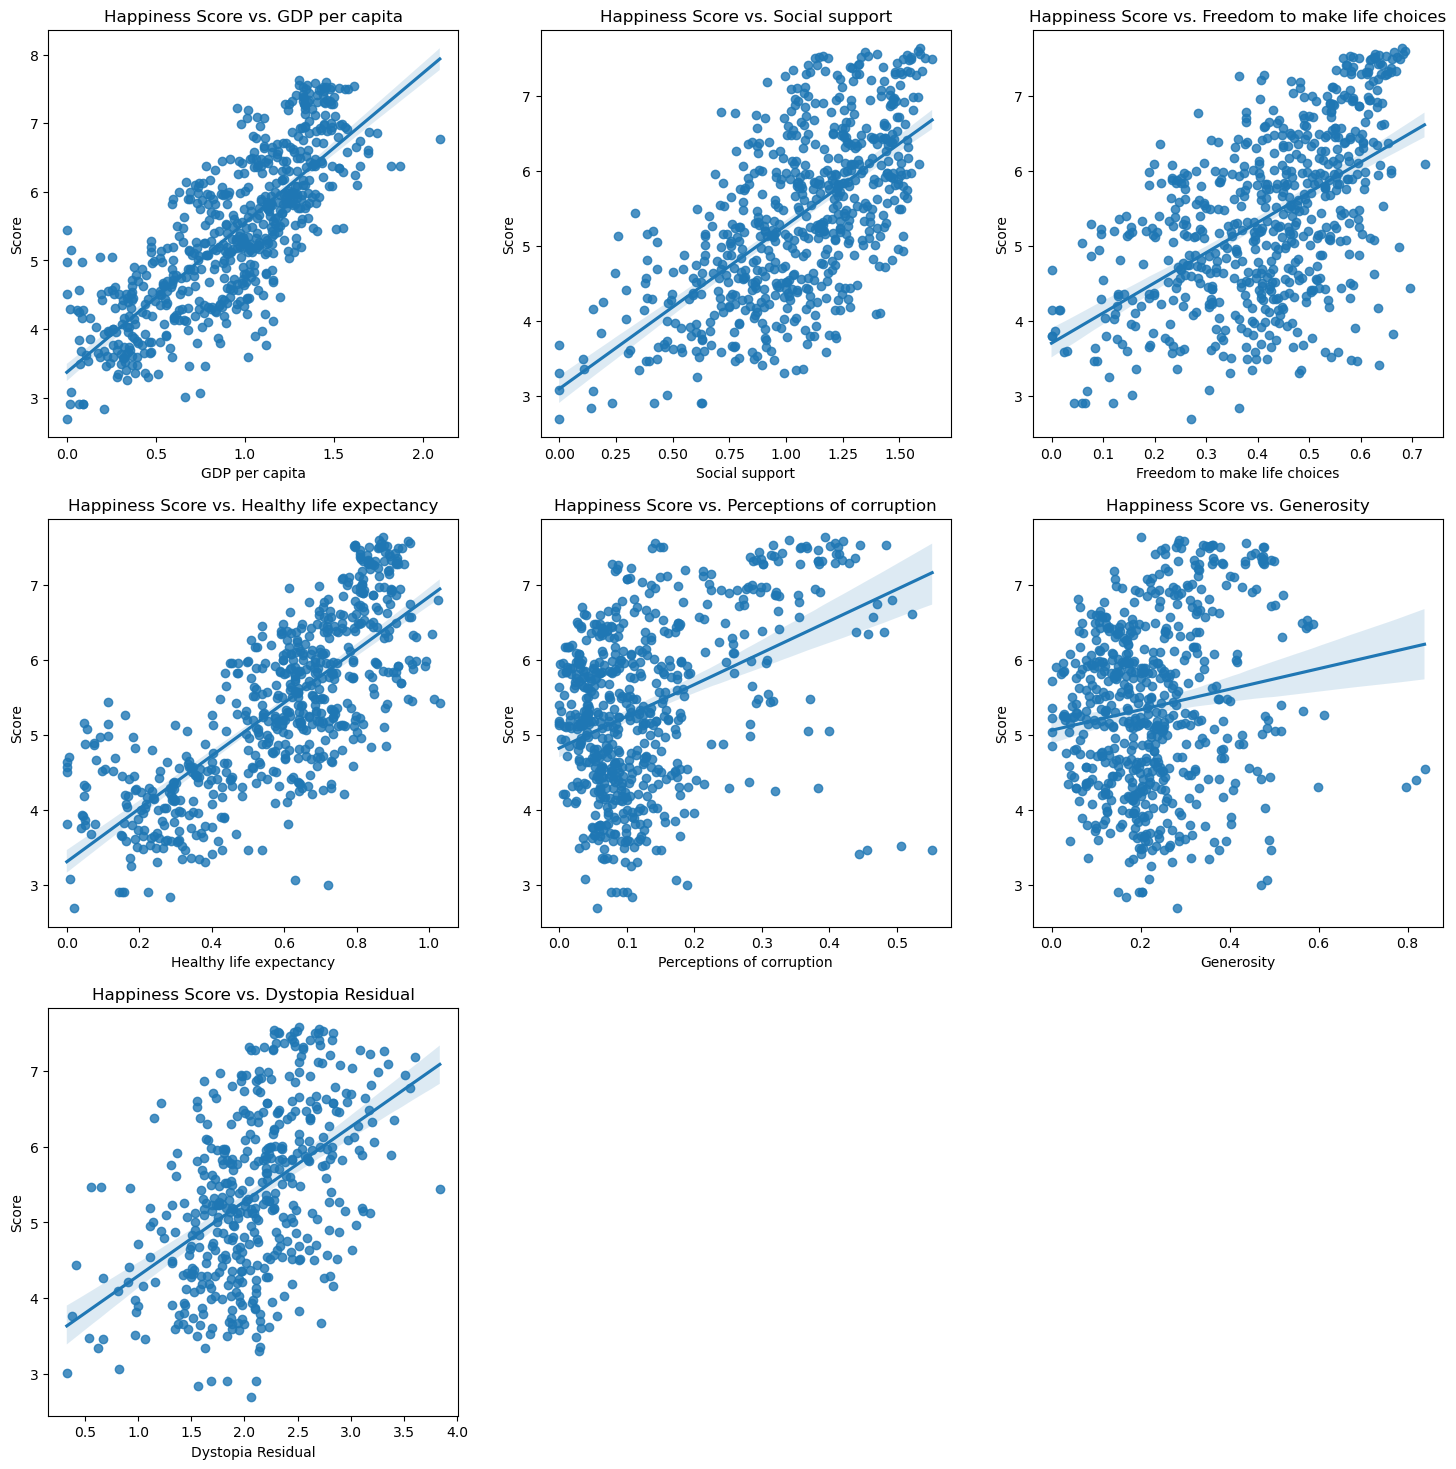

In [17]:
features = ["GDP per capita", "Social support", "Freedom to make life choices",
            "Healthy life expectancy", "Perceptions of corruption", "Generosity", "Dystopia Residual"]
score_data = df_all_years[["Score"] + features]

plt.figure(figsize=(18, 18))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.regplot(x=feature, y="Score", data=score_data)
    plt.title(f"Happiness Score vs. {feature}")
plt.show()


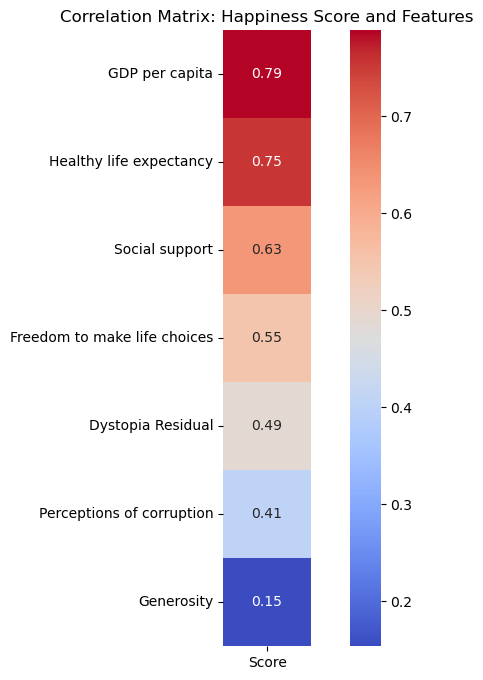

In [18]:
used_features = [f for f in features if f in df_all_years.columns]
correlation_matrix = df_all_years[["Score"] + used_features].corr()
score_correlation = correlation_matrix[["Score"]].drop("Score")
score_correlation = score_correlation.reindex(score_correlation.sort_values(by='Score', ascending=False).index)

plt.figure(figsize=(10, 8))
sns.heatmap(score_correlation, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Matrix: Happiness Score and Features")
plt.show()

r2_features = score_correlation['Score'] ** 2  # used later to select model features


**Key finding:** GDP per capita and healthy life expectancy show the strongest correlation with happiness score, followed by social support and freedom to make life choices. Perceptions of corruption and dystopia residual are moderately correlated. Generosity has the weakest correlation of any feature — consistent across all five years when broken out individually below.

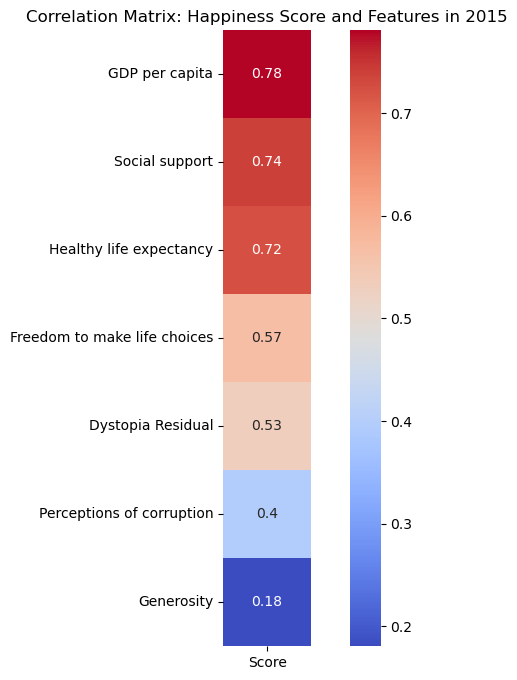

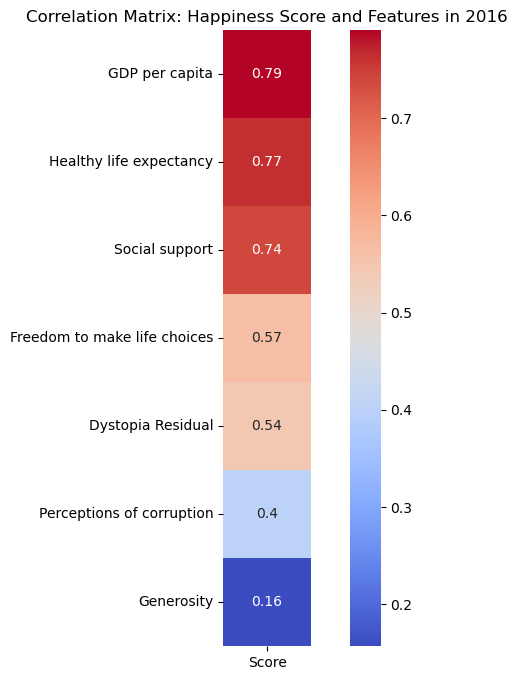

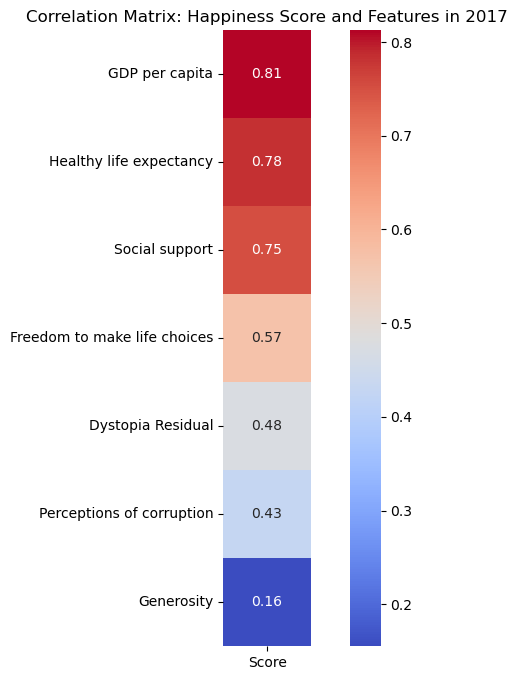

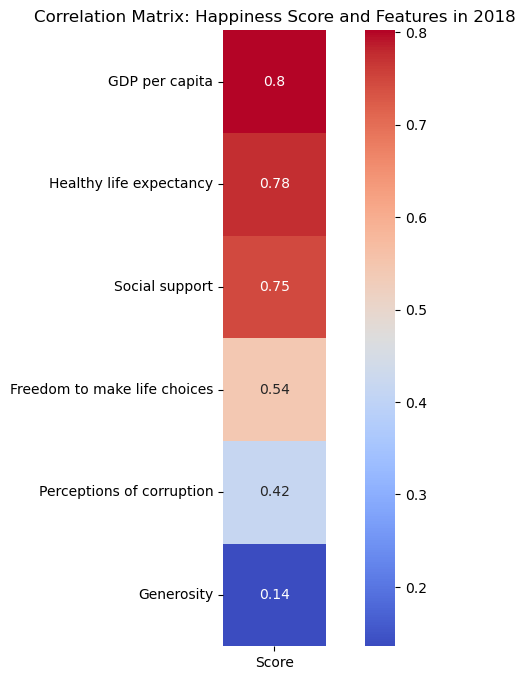

In [19]:
for year in sorted(df_all_years['Year'].unique()):
    df_year = df_all_years[df_all_years['Year'] == year]
    used = [f for f in features if not df_year[f].isna().all()]
    corr = df_year[["Score"] + used].corr()[["Score"]].drop("Score")
    corr = corr.reindex(corr.sort_values(by='Score', ascending=False).index)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)
    plt.title(f"Correlation Matrix: Happiness Score and Features in {year}")
    plt.show()


### 3.4 Regional comparison

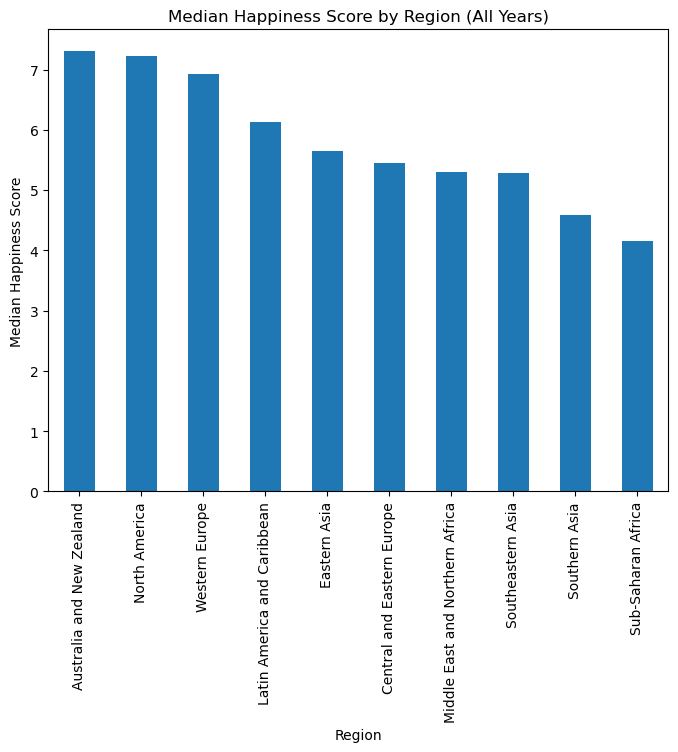

In [20]:
region_data = df_all_years.groupby('Region')['Score'].median().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
region_data.plot(kind='bar')
plt.title('Median Happiness Score by Region (All Years)')
plt.ylabel('Median Happiness Score')
plt.xlabel('Region')
plt.show()


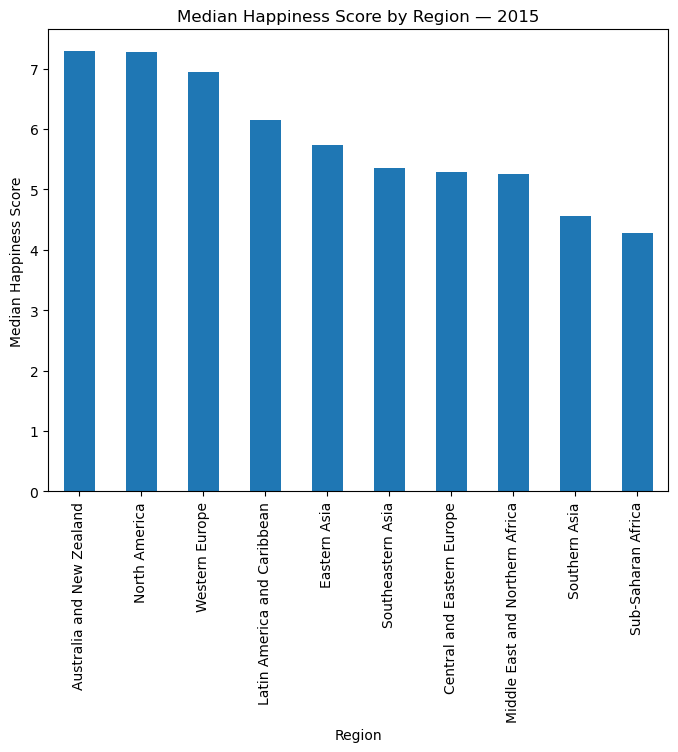

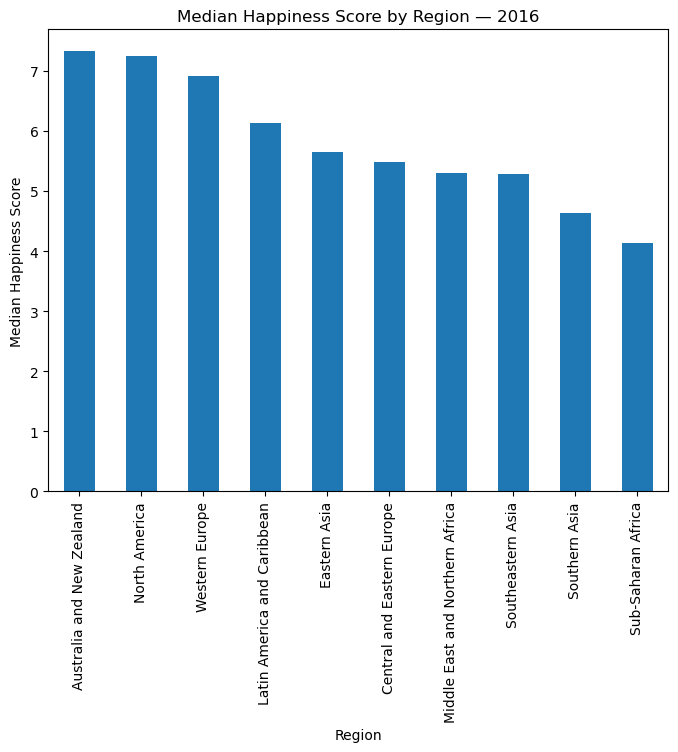

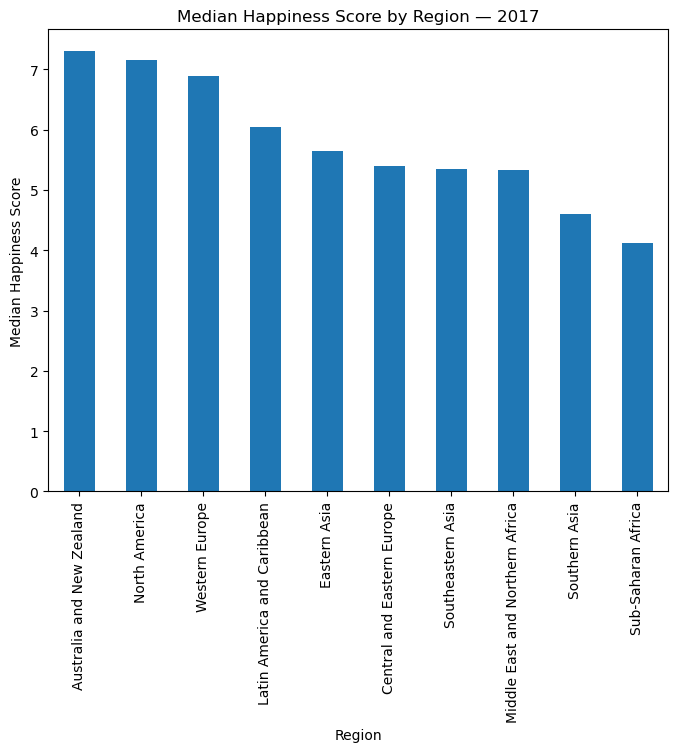

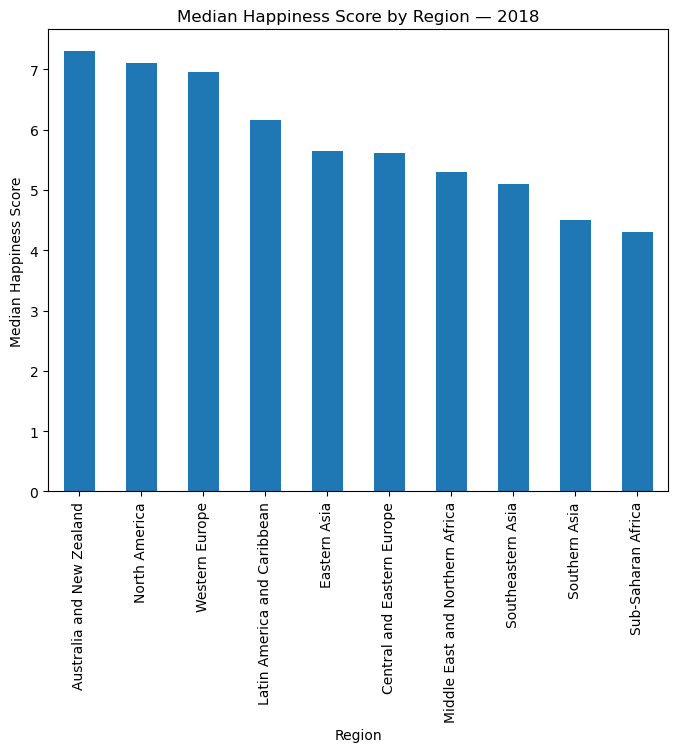

In [21]:
for year in sorted(df_all_years['Year'].unique()):
    df_year = df_all_years[df_all_years['Year'] == year]
    region_data = df_year.groupby('Region')['Score'].median().sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    region_data.plot(kind='bar')
    plt.title(f'Median Happiness Score by Region — {year}')
    plt.ylabel('Median Happiness Score')
    plt.xlabel('Region')
    plt.show()


**Key finding:** Australia/New Zealand, North America, and Western Europe consistently rank highest; Sub-Saharan Africa and Southern Asia consistently rank lowest. Regional ordering is stable year over year, which matches the trend seen in the most-stable-countries analysis above.

## 4. Predictive Modeling

We train on 2015–2018 data and evaluate on the held-out 2019 data, using features whose correlation with `Score` has r² ≥ 0.3 (chosen after testing a 0.4 threshold, which performed worse). Three models are compared: Linear Regression, KNN Regression, and Random Forest Regression.

### 4.1 Linear Regression

R^2 Score: 0.7323115534057605
MSE: 542.8498623225684


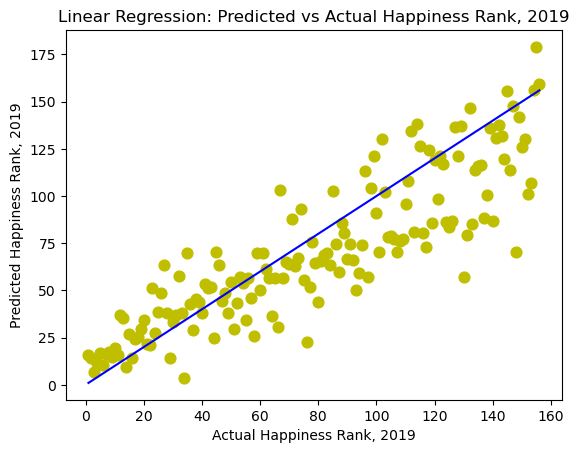

Difference Squared median: 178.14823088057187


In [22]:
train_features = [f for f in r2_features.index if r2_features[f] >= .3]
X = df_all_years[train_features]
y = df_all_years['Overall rank']

X_test = df2019[train_features]
y_test = df2019['Overall rank']

model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X_test)

print("R^2 Score:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

plt.scatter(y_test, predictions, color="y", s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="blue")
plt.xlabel('Actual Happiness Rank, 2019')
plt.ylabel('Predicted Happiness Rank, 2019')
plt.title('Linear Regression: Predicted vs Actual Happiness Rank, 2019')
plt.show()

linear_ranking = pd.DataFrame({'Predicted': predictions, 'Actual': y_test})
linear_ranking['Difference Squared'] = (linear_ranking['Predicted'] - linear_ranking['Actual']) ** 2
print(f"Difference Squared median: {linear_ranking['Difference Squared'].median()}")

# R^2 = .73, MSE = 542 — predictions typically land within 7-15 ranks of actual, with some outliers


A log transform was tested to see if it improved fit given the skew in rank data — it did not (R² dropped to .06), so the untransformed model above is used going forward.

In [23]:
X_l = np.log(X + 1)
y_l = np.log(y + 1)
X_test_l = np.log(X_test + 1)

log_model = LinearRegression()
log_model.fit(X_l, y_l)
log_predictions = np.exp(log_model.predict(X_test_l)) - 1

print("R^2 Score (log):", r2_score(y_test, log_predictions))
print("MSE (log):", mean_squared_error(y_test, log_predictions))
# Confirmed worse — log transform not used in the final comparison


R^2 Score (log): 0.06071131393716689
MSE (log): 1904.7991812782536


### 4.2 KNN Regression

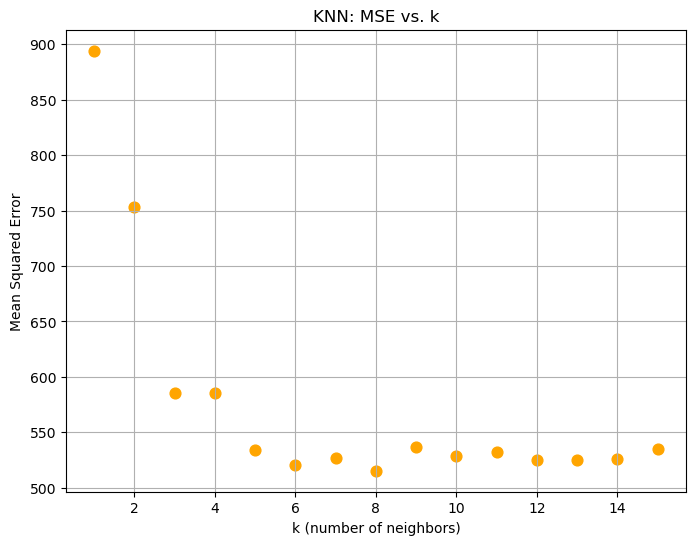

R^2: 0.7113480109370802
MSE: 585.3621794871794


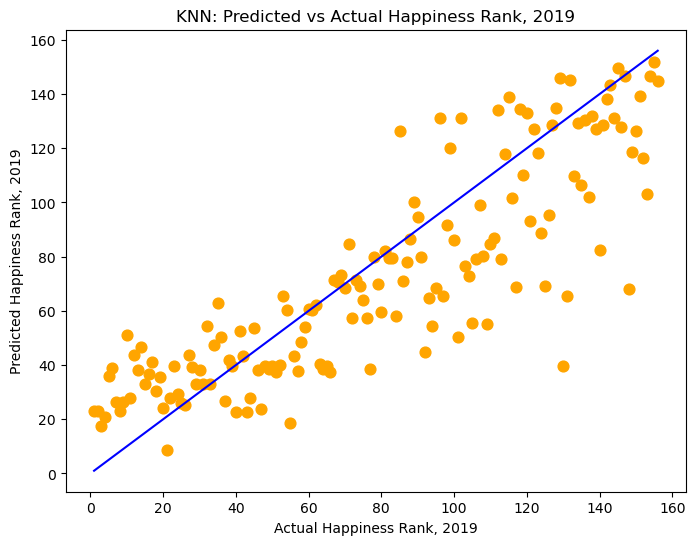

Difference Squared median: 210.25


In [24]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)
X_test_scale = scaler.transform(X_test)

mse_scores = {}
for k in range(1, 16):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_scale, y)
    predictions = knn.predict(X_test_scale)
    mse_scores[k] = mean_squared_error(y_test, predictions)

plt.figure(figsize=(8, 6))
plt.scatter(list(mse_scores.keys()), list(mse_scores.values()), color='orange', s=60)
plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean Squared Error')
plt.title("KNN: MSE vs. k")
plt.grid()
plt.show()

# Elbow point at k=4
knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_scale, y)
predictions = knn.predict(X_test_scale)

print("R^2:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='orange', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue')
plt.xlabel('Actual Happiness Rank, 2019')
plt.ylabel('Predicted Happiness Rank, 2019')
plt.title("KNN: Predicted vs Actual Happiness Rank, 2019")
plt.show()

knn_ranking = pd.DataFrame({'Predicted': predictions, 'Actual': y_test})
knn_ranking['Difference Squared'] = (knn_ranking['Predicted'] - knn_ranking['Actual']) ** 2
print(f"Difference Squared median: {knn_ranking['Difference Squared'].median()}")

# R^2 = .71, MSE = 585 — slightly worse than linear regression on both metrics


### 4.3 Random Forest Regression

In [25]:
parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 4, 10],
    'min_samples_leaf': [1, 2, 3]
}
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=40),
    param_distributions=parameters,
    n_iter=20, cv=5, scoring='r2', random_state=40, n_jobs=-1
)
random_search.fit(X, y)
print("Best parameters:", random_search.best_params_)


Best parameters: {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 5}


Random Forest R^2: 0.6863218147914164
MSE: 636.11321975424


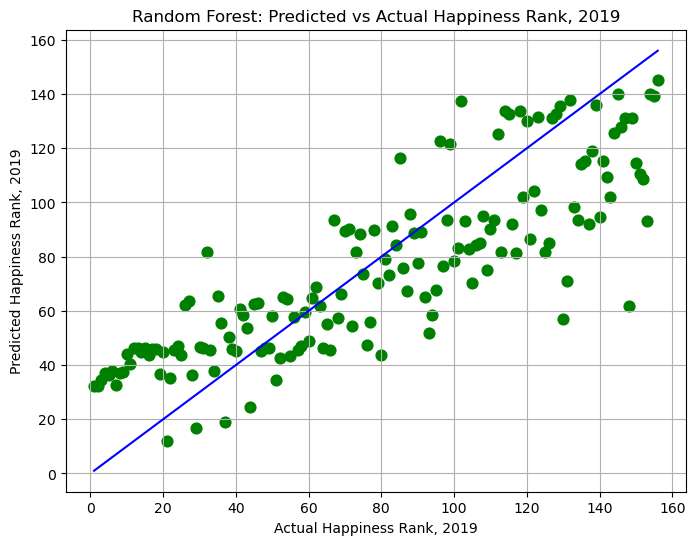

Difference Squared median: 342.88253701464424


In [26]:
params = {'n_estimators': [300], 'max_depth': [5], 'min_samples_split': [4], 'min_samples_leaf': [1]}
random_forest_model = GridSearchCV(RandomForestRegressor(random_state=40), param_grid=params, cv=5, scoring='r2')
random_forest_model.fit(X, y)

random_forest_predictions = random_forest_model.predict(X_test)
rf_r2 = r2_score(y_test, random_forest_predictions)
rf_mse = mean_squared_error(y_test, random_forest_predictions)
print("Random Forest R^2:", rf_r2)
print("MSE:", rf_mse)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, random_forest_predictions, color='green', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue')
plt.xlabel('Actual Happiness Rank, 2019')
plt.ylabel('Predicted Happiness Rank, 2019')
plt.title("Random Forest: Predicted vs Actual Happiness Rank, 2019")
plt.grid()
plt.show()

forest_ranking = pd.DataFrame({'Predicted': random_forest_predictions, 'Actual': y_test})
forest_ranking['Difference Squared'] = (forest_ranking['Predicted'] - forest_ranking['Actual']) ** 2
print(f"Difference Squared median: {forest_ranking['Difference Squared'].median()}")

# R^2 lower and MSE (780) higher than Linear Regression — Random Forest underperforms here,
# likely because the dataset is small (~470 training rows) and the relationships are largely linear


Rather than hand-picking feature weights, we can use the trained Random Forest's built-in feature importances to see which variables it relied on most — a data-driven check against the correlation analysis in Section 3.3.

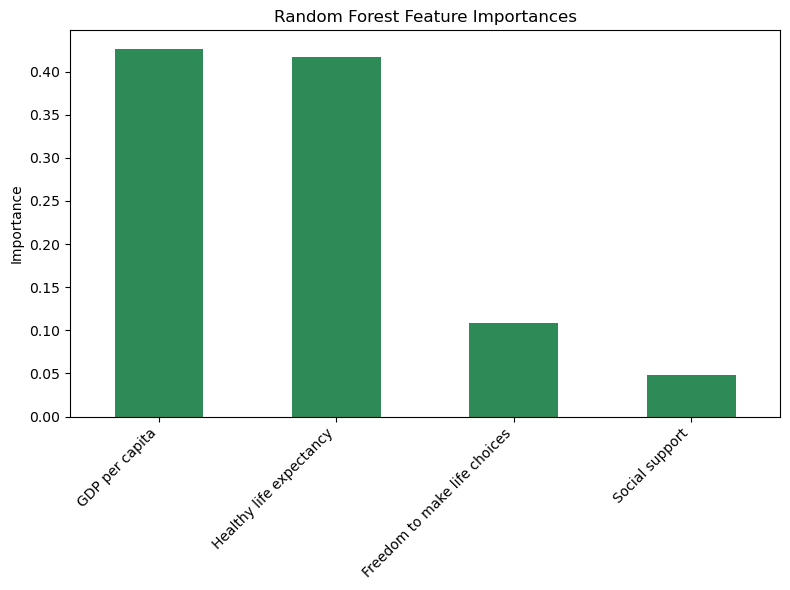

GDP per capita                  0.426565
Healthy life expectancy         0.417176
Freedom to make life choices    0.108212
Social support                  0.048047
dtype: float64


In [27]:
importances = pd.Series(
    random_forest_model.best_estimator_.feature_importances_, index=train_features
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='bar', color='seagreen')
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(importances)


## 5. Model Comparison & Conclusions

| Model | R² | MSE | Difference² Median |
|---|---|---|---|
| Linear Regression | 0.73 | 542 | 178 |
| KNN (k=4) | 0.71 | 585 | 210 |
| Random Forest | 0.68 | 636 | 342 |

**Findings:**
- Linear Regression was the best-performing model on this dataset, despite Random Forest's added complexity and hyperparameter tuning — likely because happiness rank has a largely linear relationship with GDP, life expectancy, and social support at this sample size (~470 training rows), where a more flexible model tends to overfit rather than help.
- GDP per capita and healthy life expectancy are consistently the strongest predictors of happiness across the correlation analysis, the by-year breakdowns, and the Random Forest's own feature importances — three independent checks agreeing is a good sign the finding is real rather than a modeling artifact.
- Regional and country-level trends are stable year over year: the same regions and countries persist at the top and bottom of the rankings across 2015–2018.

**Limitations & next steps:**
- Test set is a single year (2019), so model performance estimates carry meaningful variance — cross-validating across years (train on 2015–2017, test on 2018; train on 2015–2018, test on 2019, etc.) would give a more robust comparison.
- Country name reconciliation across years was done manually; a fuzzy-matching approach would scale better and reduce the risk of silent mismatches.
- Dystopia Residual is available for 2015–2017 but not 2018–2019, which limits its use as a training feature — worth revisiting whether reconstructing an equivalent value is feasible.
